In [163]:
import SimpleITK as sitk
import numpy as np

In [164]:
img = sitk.ReadImage(
    f'/Users/tomjulius/Developer/core_project/example_data/2d+t_trackrad/A_003_frames_8bit.mha'
)

In [165]:
labels= np.zeros(sitk.GetArrayFromImage(img).shape, dtype=np.uint8)
labels.shape

(167, 270, 270)

In [166]:
labels= np.zeros(sitk.GetArrayFromImage(img).shape, dtype=np.uint8)
labels[40, 30:60, 30:60] = 1
labels[42, 30:55, 30:55] = 1
labels[42, 50:70, 50:70] = 1

In [167]:
img=labels.transpose(1,2,0)
img_voxel_size=[1.0, 1.0, 1.0]
dose_voxel_size=[0.5, 0.5, 0.5]
ax_dim =2
cor_dim = 1
sag_dim = 0

In [168]:
sitk_img = sitk.GetImageFromArray(labels[40])
sitk_distance_map = sitk.GetArrayFromImage(sitk.ApproximateSignedDistanceMap(sitk_img)) # unfortunately not applicable to 3D image
sitk_distance_map.shape

(270, 270)

In [169]:
sitk_img = sitk.GetImageFromArray(labels[42])
sitk_distance_map_b = sitk.GetArrayFromImage(sitk.ApproximateSignedDistanceMap(sitk_img)) # unfortunately not applicable to 3D image
sitk_distance_map_b.shape

(270, 270)

In [170]:
distance_map= np.zeros((2,270,270), dtype=np.float32)
distance_map[0,:,:] = sitk_distance_map
distance_map[1,:,:] = sitk_distance_map_b
distance_map.shape

(2, 270, 270)

In [171]:
from scipy.interpolate import interpn

In [172]:
x, y, z = np.meshgrid([0,1,2],np.arange(270), np.arange(270)) # shape e.g. (3, 600, 600, 420)

labels_interp = interpn((np.array([0,2]), np.arange(270), np.arange(270)), distance_map, np.array([x,y,z]).T, bounds_error=False, fill_value=0)
labels_interp = labels_interp.transpose(1,0,2)
labels_interp.shape#, np.where(labels_interp.sum(axis=(0,2)) != 0)


(3, 270, 270)

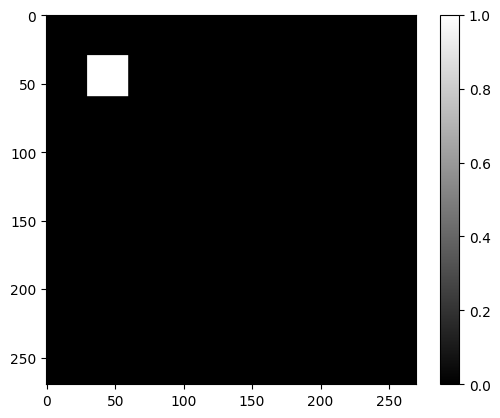

In [205]:
plt.imshow((interpolate_labels(labels[40], labels[42], 3)[0]), cmap='gray')
plt.colorbar()
plt.show()